# Faster R-CNN Experiment Comparison Notebook

Run this notebook **cell by cell** to compare:
1. Baseline
2. Anchor-size customization
3. Data augmentation
4. Backbone (ResNet-50 vs ResNet-101)

In [1]:
from pathlib import Path
import sys
import runpy
import pandas as pd
import matplotlib.pyplot as plt

SCRIPT = Path(r"C:\\wheat-detection\\src\\faster_rcnn_wheat.py")
DATA_DIR = Path(r"C:\\wheat-detection\\data")
OUT_BASE = Path(r"C:\\wheat-detection\\outputs_experiments_nb2")
OUT_BASE.mkdir(parents=True, exist_ok=True)

EPOCHS = 10
BATCH_SIZE = 4

EXPERIMENTS = [
    {
        'name': 'baseline_r50_default',
        'args': ['--backbone', 'resnet50', '--experiment-tag', 'baseline_r50_default'],
    },
    {
        'name': 'anchor_tuned_r50',
        'args': ['--backbone', 'resnet50', '--anchor-sizes', '16,24,32,48,64', '--anchor-aspects', '0.5,1.0,2.0', '--experiment-tag', 'anchor_tuned_r50'],
    },
    {
        'name': 'anchor_aug_r50',
        'args': ['--backbone', 'resnet50', '--anchor-sizes', '16,24,32,48,64', '--use-scale-jitter', '--use-random-crop', '--experiment-tag', 'anchor_aug_r50'],
    },
    {
        'name': 'anchor_aug_r101',
        'args': ['--backbone', 'resnet101', '--anchor-sizes', '16,24,32,48,64', '--use-scale-jitter', '--use-random-crop', '--experiment-tag', 'anchor_aug_r101'],
    },
]

print('Configured experiments:')
for i, e in enumerate(EXPERIMENTS):
    print(f'  {i}: {e["name"]}')

Configured experiments:
  0: baseline_r50_default
  1: anchor_tuned_r50
  2: anchor_aug_r50
  3: anchor_aug_r101


In [2]:
def run_experiment(idx: int):
    exp = EXPERIMENTS[idx]
    out_dir = OUT_BASE / exp['name']
    out_dir.mkdir(parents=True, exist_ok=True)

    args = [
        '--data-dir', str(DATA_DIR),
        '--epochs', str(EPOCHS),
        '--batch-size', str(BATCH_SIZE),
        '--output-dir', str(out_dir),
    ] + exp['args']

    print('\nRunning:', exp['name'])
    print('Output dir:', out_dir)

    old_argv = sys.argv[:]
    try:
        sys.argv = ['faster_rcnn_wheat.py'] + args
        runpy.run_path(str(SCRIPT), run_name='__main__')
    finally:
        sys.argv = old_argv

    return out_dir

print('Helper ready: run_experiment(idx)')

Helper ready: run_experiment(idx)


## Run Experiments One-by-One
Change `exp_idx` and run this cell repeatedly.

In [3]:
exp_idx = 3  # 0, 1, 2, 3
run_experiment(exp_idx)


Running: anchor_aug_r101
Output dir: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101
Device: cuda
Train images: 2699 | Val images: 674
Backbone: resnet101
Custom anchors: 16,24,32,48,64
Augmentations: hflip+vflip, scale_jitter=True, random_crop=True
Per-epoch mode: train only (evaluation runs once after training).


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Train:   0%|          | 0/675 [00:06<?, ?it/s]

Epoch 01/10 | train_loss=0.9615 | loss_cls=0.2378 | loss_box=0.4964 | loss_obj=0.1069 | loss_rpn=0.1204 | lr=1.00e-04 | epoch_time=219.4s


Train:   0%|          | 0/675 [00:06<?, ?it/s]

...

Final Train mAP50:   0%|          | 0/675 [00:06<?, ?it/s]

Final Val mAP50:   0%|          | 0/169 [00:07<?, ?it/s]

Val:   0%|          | 0/169 [00:06<?, ?it/s]

Final Evaluation | val_loss=0.6957 | train_mAP50=0.9013 | val_mAP50=0.9167 | val_pred=46.50 | val_gt=43.51
Saved preview image: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\val_prediction_preview.png
Saved training history: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\training_history.csv
Saved loss curves: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\loss_curves.png
Saved mAP50 curves: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\map50_curves.png
Saved runtime trend: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\epoch_runtime.png
Saved best model: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\best_model.pt
Saved last model: C:\wheat-detection\outputs_experiments_nb2\anchor_aug_r101\last_model.pt


WindowsPath('C:/wheat-detection/outputs_experiments_nb2/anchor_aug_r101')

## Build Comparison Table

In [4]:
rows = []
for exp in EXPERIMENTS:
    csv_path = OUT_BASE / exp['name'] / 'training_history.csv'
    if not csv_path.exists():
        continue
    df = pd.read_csv(csv_path)
    if len(df) == 0:
        continue
    row = df.iloc[-1].to_dict()
    row['experiment_name'] = exp['name']
    rows.append(row)

summary_df = pd.DataFrame(rows)
if len(summary_df) == 0:
    print('No results yet. Run at least one experiment first.')
else:
    keep_cols = [
        'experiment_name', 'experiment_tag', 'backbone', 'anchor_sizes',
        'use_scale_jitter', 'use_random_crop',
        'loss_total', 'val_loss_total', 'train_map50', 'val_map50', 'epoch_time_sec'
    ]
    keep_cols = [c for c in keep_cols if c in summary_df.columns]
    summary_df = summary_df[keep_cols].sort_values('val_map50', ascending=False)
    display(summary_df)
    summary_path = OUT_BASE / 'experiment_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print('Saved:', summary_path)

,experiment_name,experiment_tag,backbone,anchor_sizes,use_scale_jitter,use_random_crop,loss_total,val_loss_total,train_map50,val_map50,epoch_time_sec
1,anchor_tuned_r50,anchor_tuned_r50,resnet50,"16,24,32,48,64",False,False,0.618115,0.662794,0.937176,0.925471,648.670602
0,baseline_r50_default,baseline_r50_default,resnet50,default,False,False,0.662526,0.708730,0.935782,0.922801,218.195277
3,anchor_aug_r101,anchor_aug_r101,resnet101,"16,24,32,48,64",True,True,0.708035,0.695727,0.901312,0.916702,218.952677
2,anchor_aug_r50,anchor_aug_r50,resnet50,"16,24,32,48,64",True,True,0.713700,0.678893,0.900428,0.916465,247.290412


Saved: C:\wheat-detection\outputs_experiments_nb2\experiment_summary.csv


## Plot val_mAP50 Comparison

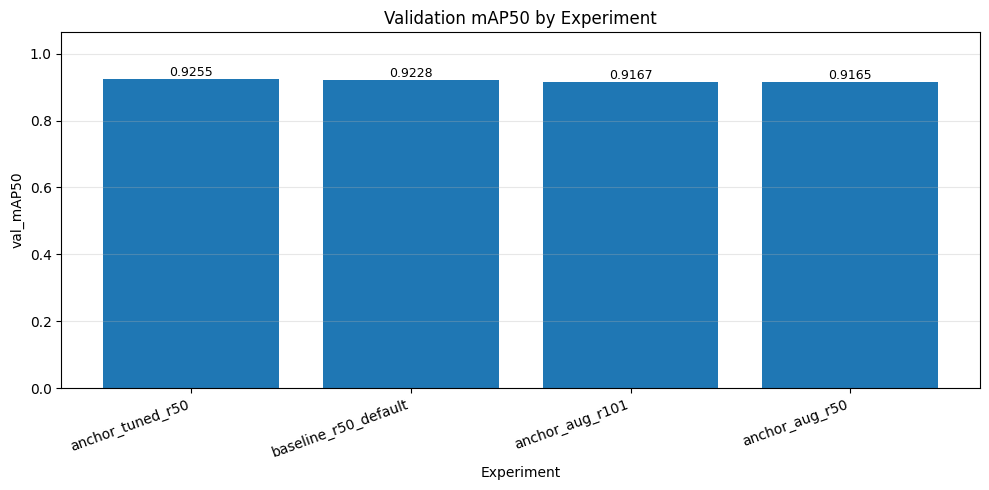

Saved: C:\wheat-detection\outputs_experiments_nb2\val_map50_comparison.png


In [5]:
summary_path = OUT_BASE / 'experiment_summary.csv'
if not summary_path.exists():
    raise FileNotFoundError(f'Missing {summary_path}. Run summary cell first.')

plot_df = pd.read_csv(summary_path).sort_values('val_map50', ascending=False)
labels = plot_df['experiment_name'].astype(str).tolist()
vals = plot_df['val_map50'].astype(float).tolist()

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, vals)
plt.ylabel('val_mAP50')
plt.xlabel('Experiment')
plt.title('Validation mAP50 by Experiment')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.ylim(0, max(vals) * 1.15 if len(vals) else 1)
for b, v in zip(bars, vals):
    plt.text(b.get_x() + b.get_width()/2, b.get_height(), f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
fig_path = OUT_BASE / 'val_map50_comparison.png'
plt.savefig(fig_path)
plt.show()
print('Saved:', fig_path)